In [1]:
import os
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import numpy as np
from datetime import datetime

# Add project root to path so we can import our modules
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import Ultralytics YOLO
from ultralytics import YOLO

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Create output directory for plots
output_dir = Path("../outputs/training")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Setup complete")
print(f"📁 Project root: {project_root}")
print(f"📊 Output directory: {output_dir}")

✅ Setup complete
📁 Project root: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai
📊 Output directory: ../outputs/training


### Dataset Validation

In [2]:
# Load dataset configuration
data_yaml_path = project_root / "data" / "processed" / "SKU110K_yolo" / "data.yaml"

if not data_yaml_path.exists():
    print(f"❌ Error: Dataset configuration not found at {data_yaml_path}")
    print("   Please run: python scripts/prepare_data.py")
else:
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    
    print("✅ Dataset configuration loaded")
    print(f"\n📋 Configuration:")
    print(f"   Path: {data_config['path']}")
    print(f"   Classes: {data_config['nc']} ({data_config['names']})")
    print(f"   Train: {data_config['train']}")
    print(f"   Val: {data_config['val']}")
    print(f"   Test: {data_config['test']}")
    
    # Count images in each split
    dataset_root = Path(data_config['path'])
    for split in ['train', 'val', 'test']:
        split_dir = dataset_root / data_config[split]
        if split_dir.exists():
            image_count = len(list(split_dir.glob('*.jpg')))
            print(f"\n   {split.capitalize()} images: {image_count:,}")
        else:
            print(f"   ❌ {split.capitalize()} directory not found!")
    
    # Check label files
    train_labels = dataset_root / data_config['train'] / 'labels'
    print(train_labels)
    if train_labels.exists():
        label_count = len(list(train_labels.glob('*.txt')))
        print(f"\n   Train labels: {label_count:,}")
    
    print(f"\n✅ Dataset validation complete")

✅ Dataset configuration loaded

📋 Configuration:
   Path: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo
   Classes: 1 (['object'])
   Train: images/train
   Val: images/val
   Test: images/test

   Train images: 8,219

   Val images: 588

   Test images: 2,936
/Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/images/train/labels

✅ Dataset validation complete


### Visualize Sample Images

/Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/images/train
/Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/labels/train


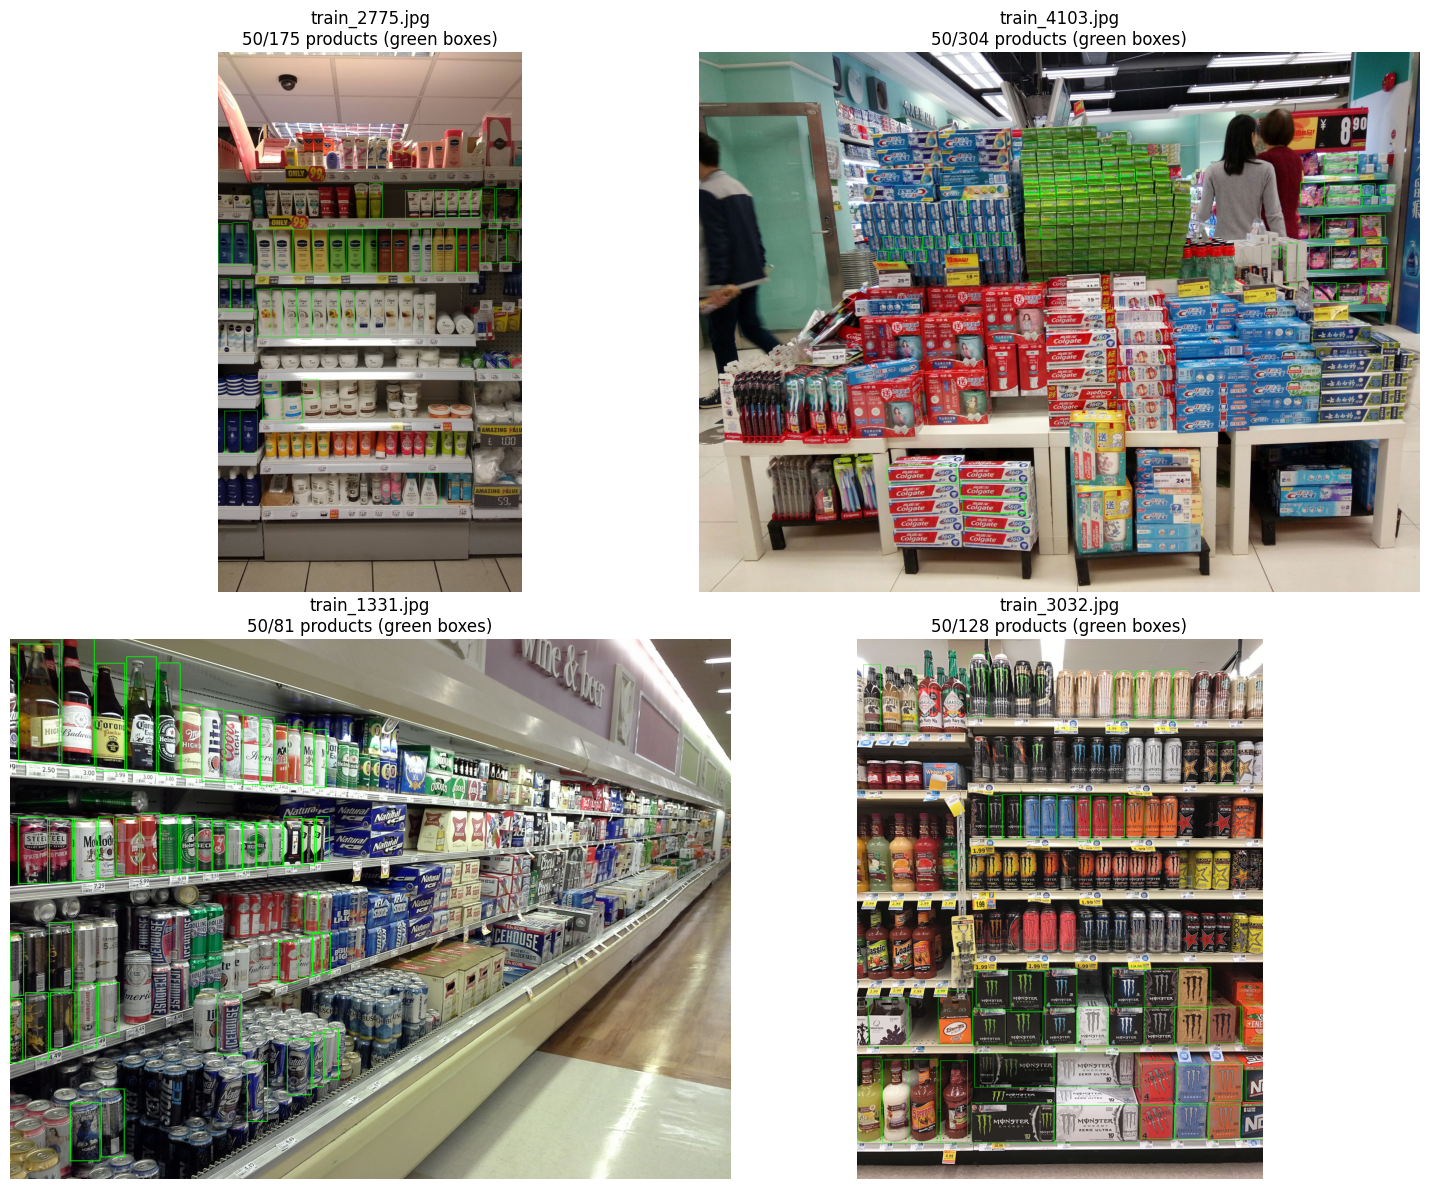

✅ Sample images saved to ../outputs/training/sample_images.png


In [3]:
def visualize_yolo_annotations(image_path, label_path, max_boxes=50):
    """
    Visualize YOLO format annotations on image.
    YOLO format: class_id x_center y_center width height (all normalized 0-1)
    """
    # Read image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    # Read labels
    if label_path.exists():
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        # Draw bounding boxes (limit to max_boxes for readability)
        for i, line in enumerate(lines[:max_boxes]):
            class_id, x_center, y_center, width, height = map(float, line.strip().split())
            
            # Convert from YOLO format to pixel coordinates
            x1 = int((x_center - width/2) * w)
            y1 = int((y_center - height/2) * h)
            x2 = int((x_center + width/2) * w)
            y2 = int((y_center + height/2) * h)
            
            # Draw rectangle
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        box_count = len(lines)
        displayed = min(box_count, max_boxes)
    else:
        box_count = 0
        displayed = 0
    
    return img, box_count, displayed

# Visualize 4 random training images
train_images_dir = dataset_root / data_config['train']
print(train_images_dir)
train_labels_dir = dataset_root / 'labels'/ 'train'
print(train_labels_dir)
train_images = list(train_images_dir.glob('*.jpg'))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

np.random.seed(42)
sample_indices = np.random.choice(len(train_images), 4, replace=False)

for idx, ax in enumerate(axes):
    img_path = train_images[sample_indices[idx]]
    label_path = train_labels_dir / f"{img_path.stem}.txt"
    
    img, total_boxes, displayed_boxes = visualize_yolo_annotations(img_path, label_path)
    
    ax.imshow(img)
    ax.set_title(f"{img_path.name}\n{displayed_boxes}/{total_boxes} products (green boxes)")
    ax.axis('off')

plt.tight_layout()
plt.savefig(output_dir / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Sample images saved to {output_dir / 'sample_images.png'}")

### Configurate the Training

In [4]:
# Training configuration
TRAINING_CONFIG = {
    'model': 'yolov8s.pt',  # Small model (11M params, 21.5MB)
    'epochs': 5,
    'batch': 16,
    'imgsz': 640,
    'patience': 10,  # Early stopping
    'device': '',  # Auto-detect GPU/CPU
    'optimizer': 'AdamW',
    'lr0': 0.01,  # Initial learning rate
    'lrf': 0.01,  # Final learning rate (lr0 * lrf)
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3.0,
    'save_period': 10,  # Save checkpoint every 10 epochs
    'workers': 8,
    'project': str(project_root / 'runs' / 'detect'),
    'name': 'train',
    'exist_ok': True
}

print("📋 Training Configuration:")
for key, value in TRAINING_CONFIG.items():
    print(f"   {key}: {value}")

# Initialize model
print(f"\n🔄 Loading model: {TRAINING_CONFIG['model']}")
model = YOLO(TRAINING_CONFIG['model'])

print(f"✅ Model loaded successfully")
print(f"   Architecture: YOLOv8s")
print(f"   Parameters: ~11M")
print(f"   Pretrained: ImageNet + COCO")

📋 Training Configuration:
   model: yolov8s.pt
   epochs: 5
   batch: 16
   imgsz: 640
   patience: 10
   device: 
   optimizer: AdamW
   lr0: 0.01
   lrf: 0.01
   momentum: 0.937
   weight_decay: 0.0005
   warmup_epochs: 3.0
   save_period: 10
   workers: 8
   project: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai/runs/detect
   name: train
   exist_ok: True

🔄 Loading model: yolov8s.pt
✅ Model loaded successfully
   Architecture: YOLOv8s
   Parameters: ~11M
   Pretrained: ImageNet + COCO


### Start Training

In [5]:
# Start training
start_time = datetime.now()
print(f"🚀 Training started at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 Progress will be displayed below...\n")

try:
    results = model.train(
        data=str(data_yaml_path),
        epochs=TRAINING_CONFIG['epochs'],
        batch=TRAINING_CONFIG['batch'],
        imgsz=TRAINING_CONFIG['imgsz'],
        device=TRAINING_CONFIG['device'],
        patience=TRAINING_CONFIG['patience'],
        optimizer=TRAINING_CONFIG['optimizer'],
        lr0=TRAINING_CONFIG['lr0'],
        lrf=TRAINING_CONFIG['lrf'],
        momentum=TRAINING_CONFIG['momentum'],
        weight_decay=TRAINING_CONFIG['weight_decay'],
        warmup_epochs=TRAINING_CONFIG['warmup_epochs'],
        save=True,
        save_period=TRAINING_CONFIG['save_period'],
        val=True,
        plots=True,
        rect=False,  # Disable rectangular training - more robust to corrupted images
        cache=False,  # Don't cache images - skip corrupted ones on-the-fly
        project=TRAINING_CONFIG['project'],
        name=TRAINING_CONFIG['name'],
        exist_ok=TRAINING_CONFIG['exist_ok']
    )
    
    end_time = datetime.now()
    duration = end_time - start_time
    
    print(f"\n✅ Training completed successfully!")
    print(f"⏱️  Duration: {duration}")
    print(f"📁 Results saved to: {results.save_dir}")
    
except KeyboardInterrupt:
    print(f"\n⚠️  Training interrupted by user")
    print(f"   You can resume training later by setting resume=True")
    
except Exception as e:
    print(f"\n❌ Training failed: {e}")
    raise

🚀 Training started at 2025-12-27 15:05:21
📊 Progress will be displayed below...

New https://pypi.org/project/ultralytics/8.3.241 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.236 🚀 Python-3.11.9 torch-2.9.1 CPU (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai/data/processed/SKU110K_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rat

Corrupt JPEG data: premature end of data segment


        1/5         0G       1.86      1.233       1.19       4022        640: 7% ╸─────────── 38/514 11.5s/it 8:03<1:30:54

Corrupt JPEG data: 562 extraneous bytes before marker 0xd9


        1/5         0G      1.786      1.117      1.153       4254        640: 11% ━─────────── 57/514 11.4s/it 11:43<1:26:35

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 21% ━━╸───────── 4/19 11.2s/it 33.5s<2:48

Corrupt JPEG data: 366 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 74% ━━━━━━━━╸─── 14/19 6.0s/it 1:35<30.1s

Corrupt JPEG data: premature end of data segment


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 6.2s/it 1:585.5ss
                   all        588      90968      0.889      0.813      0.884      0.553
Speed: 0.5ms preprocess, 165.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai/runs/detect/train

✅ Training completed successfully!
⏱️  Duration: 8:13:07.185035
📁 Results saved to: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai/runs/detect/train


### Analyze Training Result

In [6]:
# Find the latest training run
runs_dir = project_root / 'runs' / 'detect'
train_runs = sorted([d for d in runs_dir.iterdir() if d.is_dir() and d.name.startswith('train')])

if not train_runs:
    print("❌ No training runs found. Please run the training cell first.")
else:
    latest_run = train_runs[-1]
    results_csv = latest_run / 'results.csv'
    
    if not results_csv.exists():
        print(f"❌ Results file not found: {results_csv}")
    else:
        # Load training results
        df = pd.read_csv(results_csv)
        
        # Clean column names (remove leading/trailing spaces)
        df.columns = df.columns.str.strip()
        
        print(f"✅ Loaded results from: {latest_run.name}")
        print(f"   Total epochs trained: {len(df)}")
        print(f"\n📊 Final Metrics (Epoch {len(df)}):")
        
        # Get final epoch metrics
        final = df.iloc[-1]
        print(f"   Train Loss (Box): {final['train/box_loss']:.4f}")
        print(f"   Train Loss (Class): {final['train/cls_loss']:.4f}")
        print(f"   Train Loss (DFL): {final['train/dfl_loss']:.4f}")
        print(f"   Validation Precision: {final['metrics/precision(B)']:.3f}")
        print(f"   Validation Recall: {final['metrics/recall(B)']:.3f}")
        print(f"   Validation mAP@0.5: {final['metrics/mAP50(B)']:.3f}")
        print(f"   Validation mAP@0.5:0.95: {final['metrics/mAP50-95(B)']:.3f}")
        
        print(f"\n🏆 Best Metrics:")
        print(f"   Best mAP@0.5: {df['metrics/mAP50(B)'].max():.3f} (Epoch {df['metrics/mAP50(B)'].idxmax() + 1})")
        print(f"   Best mAP@0.5:0.95: {df['metrics/mAP50-95(B)'].max():.3f} (Epoch {df['metrics/mAP50-95(B)'].idxmax() + 1})")
        print(f"   Best Precision: {df['metrics/precision(B)'].max():.3f} (Epoch {df['metrics/precision(B)'].idxmax() + 1})")
        print(f"   Best Recall: {df['metrics/recall(B)'].max():.3f} (Epoch {df['metrics/recall(B)'].idxmax() + 1})")

✅ Loaded results from: train
   Total epochs trained: 5

📊 Final Metrics (Epoch 5):
   Train Loss (Box): 1.3841
   Train Loss (Class): 0.6444
   Train Loss (DFL): 0.9877
   Validation Precision: 0.889
   Validation Recall: 0.814
   Validation mAP@0.5: 0.884
   Validation mAP@0.5:0.95: 0.553

🏆 Best Metrics:
   Best mAP@0.5: 0.884 (Epoch 5)
   Best mAP@0.5:0.95: 0.553 (Epoch 5)
   Best Precision: 0.889 (Epoch 5)
   Best Recall: 0.814 (Epoch 5)


### Training Loss Curves

Visualize how training and validation losses evolved over epochs.

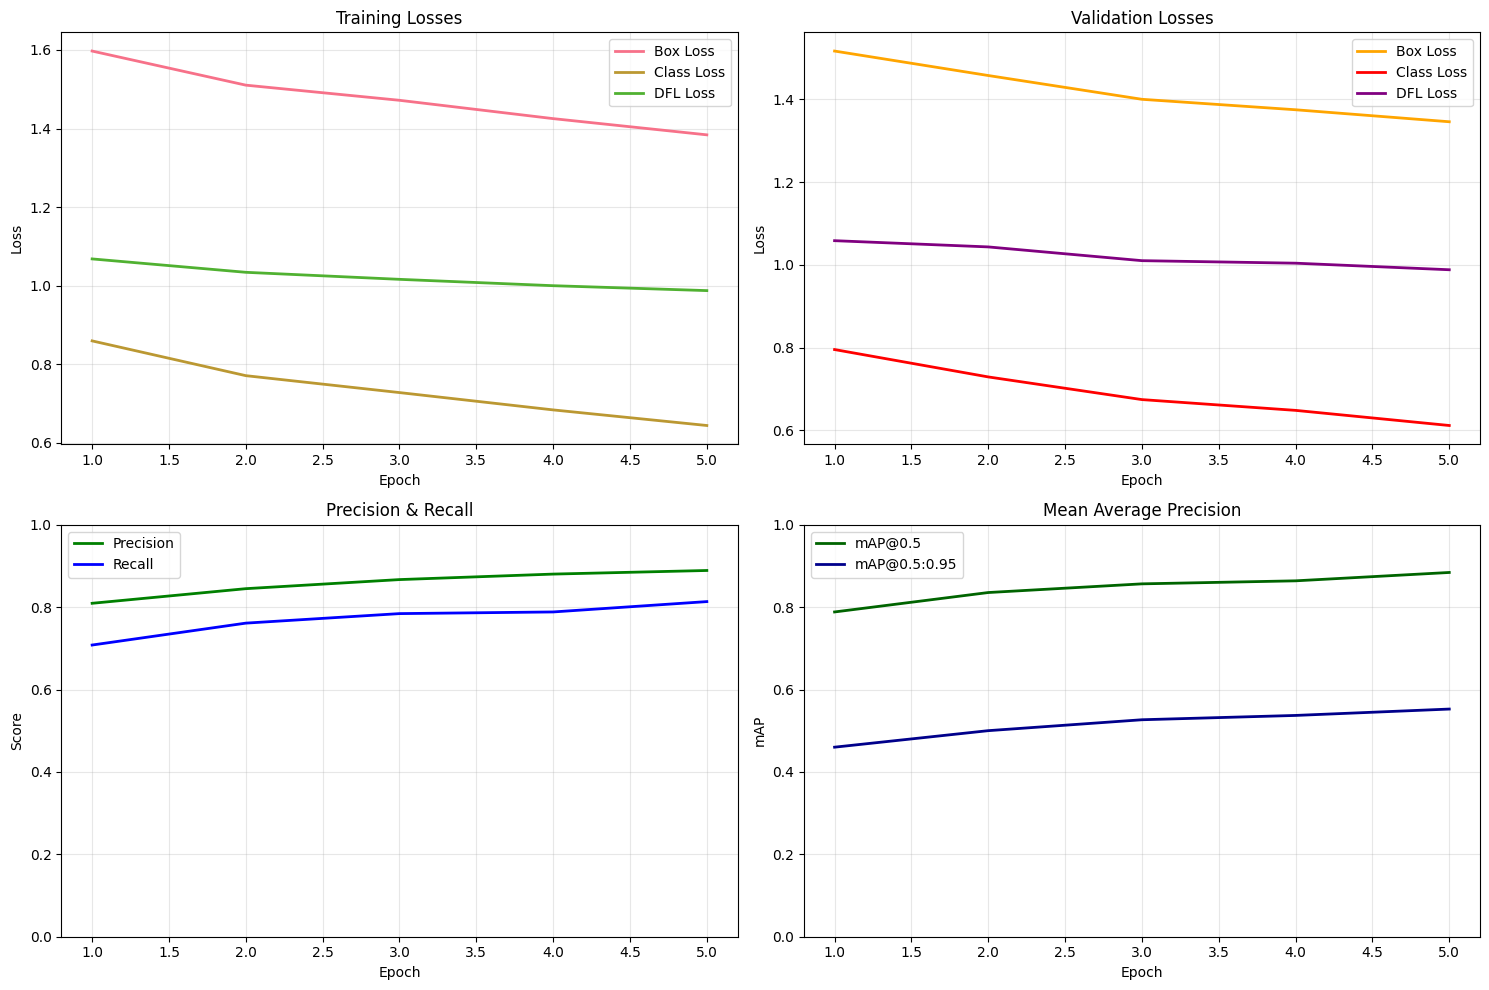

✅ Training curves saved to ../outputs/training/training_curves.png


In [7]:
if train_runs and results_csv.exists():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot training losses
    axes[0, 0].plot(df.index + 1, df['train/box_loss'], label='Box Loss', linewidth=2)
    axes[0, 0].plot(df.index + 1, df['train/cls_loss'], label='Class Loss', linewidth=2)
    axes[0, 0].plot(df.index + 1, df['train/dfl_loss'], label='DFL Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Losses')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot validation losses
    axes[0, 1].plot(df.index + 1, df['val/box_loss'], label='Box Loss', linewidth=2, color='orange')
    axes[0, 1].plot(df.index + 1, df['val/cls_loss'], label='Class Loss', linewidth=2, color='red')
    axes[0, 1].plot(df.index + 1, df['val/dfl_loss'], label='DFL Loss', linewidth=2, color='purple')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Validation Losses')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot precision and recall
    axes[1, 0].plot(df.index + 1, df['metrics/precision(B)'], label='Precision', linewidth=2, color='green')
    axes[1, 0].plot(df.index + 1, df['metrics/recall(B)'], label='Recall', linewidth=2, color='blue')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Precision & Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])
    
    # Plot mAP scores
    axes[1, 1].plot(df.index + 1, df['metrics/mAP50(B)'], label='mAP@0.5', linewidth=2, color='darkgreen')
    axes[1, 1].plot(df.index + 1, df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', linewidth=2, color='darkblue')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('mAP')
    axes[1, 1].set_title('Mean Average Precision')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(output_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Training curves saved to {output_dir / 'training_curves.png'}")

## Evaluate Model on Test Set

Load the best model and evaluate it on the test set (2,936 images).

In [8]:
if train_runs:
    # Load the best model
    best_model_path = latest_run / 'weights' / 'best.pt'
    
    if not best_model_path.exists():
        print(f"❌ Best model not found: {best_model_path}")
    else:
        print(f"🔄 Loading best model from: {best_model_path}")
        best_model = YOLO(str(best_model_path))
        
        print(f"🧪 Evaluating on test set (2,936 images)...")
        print(f"   This will take approximately 5-10 minutes...\n")
        
        # Run evaluation on test set
        test_results = best_model.val(
            data=str(data_yaml_path),
            split='test',
            batch=16,
            imgsz=640,
            plots=True,
            save_json=True,
            project=str(project_root / 'runs' / 'detect'),
            name='test',
            exist_ok=True
        )
        
        print(f"\n✅ Test Set Evaluation Complete")
        print(f"\n📊 Test Set Metrics:")
        print(f"   Precision: {test_results.box.p[0]:.3f}")
        print(f"   Recall: {test_results.box.r[0]:.3f}")
        print(f"   mAP@0.5: {test_results.box.map50:.3f}")
        print(f"   mAP@0.5:0.95: {test_results.box.map:.3f}")
        
        # Check if meets requirements
        print(f"\n✅ Requirements Check:")
        req_precision = 0.90
        req_recall = 0.85
        req_map50 = 0.85
        
        precision_ok = test_results.box.p[0] >= req_precision
        recall_ok = test_results.box.r[0] >= req_recall
        map50_ok = test_results.box.map50 >= req_map50
        
        print(f"   Precision ≥ {req_precision}: {'✅' if precision_ok else '❌'} ({test_results.box.p[0]:.3f})")
        print(f"   Recall ≥ {req_recall}: {'✅' if recall_ok else '❌'} ({test_results.box.r[0]:.3f})")
        print(f"   mAP@0.5 ≥ {req_map50}: {'✅' if map50_ok else '❌'} ({test_results.box.map50:.3f})")
        
        if precision_ok and recall_ok and map50_ok:
            print(f"\n🎉 Model meets all performance requirements!")
        else:
            print(f"\n⚠️  Model does not meet all requirements. Consider:")
            print(f"   - Training for more epochs")
            print(f"   - Using a larger model (yolov8m or yolov8l)")
            print(f"   - Adjusting hyperparameters (learning rate, augmentation)")
else:
    print("❌ No training runs found. Please run the training cell first.")

🔄 Loading best model from: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai/runs/detect/train/weights/best.pt
🧪 Evaluating on test set (2,936 images)...
   This will take approximately 5-10 minutes...

Ultralytics 8.3.236 🚀 Python-3.11.9 torch-2.9.1 CPU (Apple M3 Pro)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 1984.9±413.0 MB/s, size: 1148.6 KB)
val: Scanning /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/labels/test... 36 images, 0 backgrounds, 0 corrupt: 1% ──────────── 36/2936 107.2it/s 0.1s<27.0s

Python(32026) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


val: Scanning /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/labels/test... 2935 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2936/2936 1.1Kit/s 2.6s0.1ss
val: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/images/test/test_1029.jpg: corrupt JPEG restored and saved
val: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/images/test/test_1035.jpg: corrupt JPEG restored and saved
val: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/images/test/test_1059.jpg: corrupt JPEG restored and saved
val: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-monitoring/data/processed/SKU110K_yolo/images/test/test_1086.jpg: corrupt JPEG restored and saved
val: /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpac

Corrupt JPEG data: 935 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 13% ━╸────────── 24/184 3.9s/it 1:36<10:30

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 79% ━━━━━━━━━╸── 146/184 3.6s/it 8:46<2:17

Corrupt JPEG data: 241 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 90% ━━━━━━━━━━╸─ 166/184 2.9s/it 9:44<51.5s

Corrupt JPEG data: 555 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 184/184 3.5s/it 10:373.0ss
                   all       2935     431419      0.888      0.828      0.902      0.565
Speed: 0.3ms preprocess, 190.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Saving /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai/runs/detect/test/predictions.json...
Results saved to /Users/ducnguyenhuu/Documents/GitHub/DucNguyen_LearningSpace/retail-shelf-ai/runs/detect/test

✅ Test Set Evaluation Complete

📊 Test Set Metrics:
   Precision: 0.888
   Recall: 0.828
   mAP@0.5: 0.902
   mAP@0.5:0.95: 0.565

✅ Requirements Check:
   Precision ≥ 0.9: ❌ (0.888)
   Recall ≥ 0.85: ❌ (0.828)
   mAP@0.5 ≥ 0.85: ✅ (0.902)

⚠️  Model does not meet all requirements. Consider:
   - Training for more epochs
   - Using a larger model (yolov8m or yolov8l)
   - Adjusting hyperparameters (learning rate, augmentation)
